<a href="https://www.pieriandata.com"><img src="../Pierian_Data_Logo.PNG"></a>
<strong><center>Copyright by Pierian Data Inc.</center></strong> 
<strong><center>Created by Jose Marcial Portilla.</center></strong>
# CIFAR-10 Multiple Classes

Let's go over another example of using Keras and building out CNNs. This time will use another famous data set, the CIFAR-10 dataset which consists of 10 different image types.

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

In [3]:
import tensorflow as tf

In [4]:
tf.__version__

'2.19.0'

-----

# The Data

CIFAR-10 is a dataset of 50,000 32x32 color training images, labeled over 10 categories, and 10,000 test images.

In [5]:
dir(tf.keras)

['DTypePolicy',
 'FloatDTypePolicy',
 'Function',
 'Initializer',
 'Input',
 'InputSpec',
 'KerasTensor',
 'Layer',
 'Loss',
 'Metric',
 'Model',
 'Operation',
 'Optimizer',
 'Quantizer',
 'Regularizer',
 'RematScope',
 'Sequential',
 'StatelessScope',
 'SymbolicScope',
 'Variable',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 'activations',
 'applications',
 'backend',
 'callbacks',
 'config',
 'constraints',
 'datasets',
 'device',
 'distillation',
 'distribution',
 'dtype_policies',
 'export',
 'initializers',
 'layers',
 'legacy',
 'losses',
 'metrics',
 'mixed_precision',
 'models',
 'name_scope',
 'ops',
 'optimizers',
 'preprocessing',
 'quantizers',
 'random',
 'regularizers',
 'remat',
 'tree',
 'utils',
 'version',
 'visualization',
 'wrappers']

In [6]:
dir(tf.keras.datasets)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'boston_housing',
 'california_housing',
 'cifar10',
 'cifar100',
 'fashion_mnist',
 'imdb',
 'mnist',
 'reuters']

In [7]:
from tensorflow.keras.datasets import cifar10

In [8]:
type(cifar10)

module

In [9]:
dir(cifar10)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'load_data']

In [16]:
(x_train , y_train) , (x_test , y_test) = cifar10.load_data()

In [17]:
x_train.shape

(50000, 32, 32, 3)

In [18]:
x_train[0].shape

(32, 32, 3)

In [19]:
import matplotlib.pyplot as plt

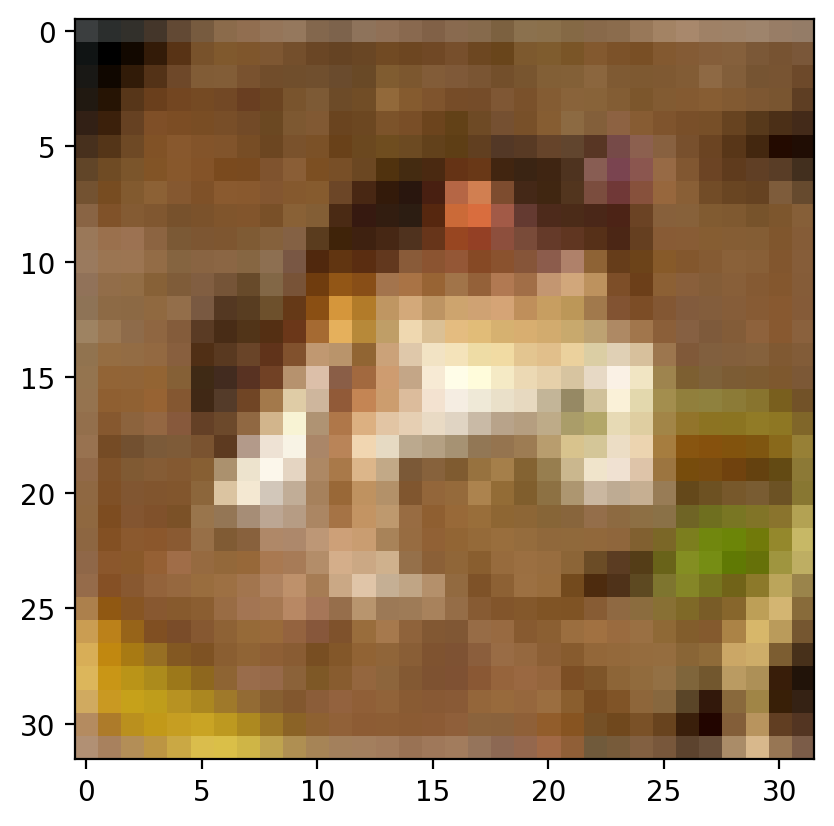

In [20]:
# FROG
plt.imshow(x_train[0]);

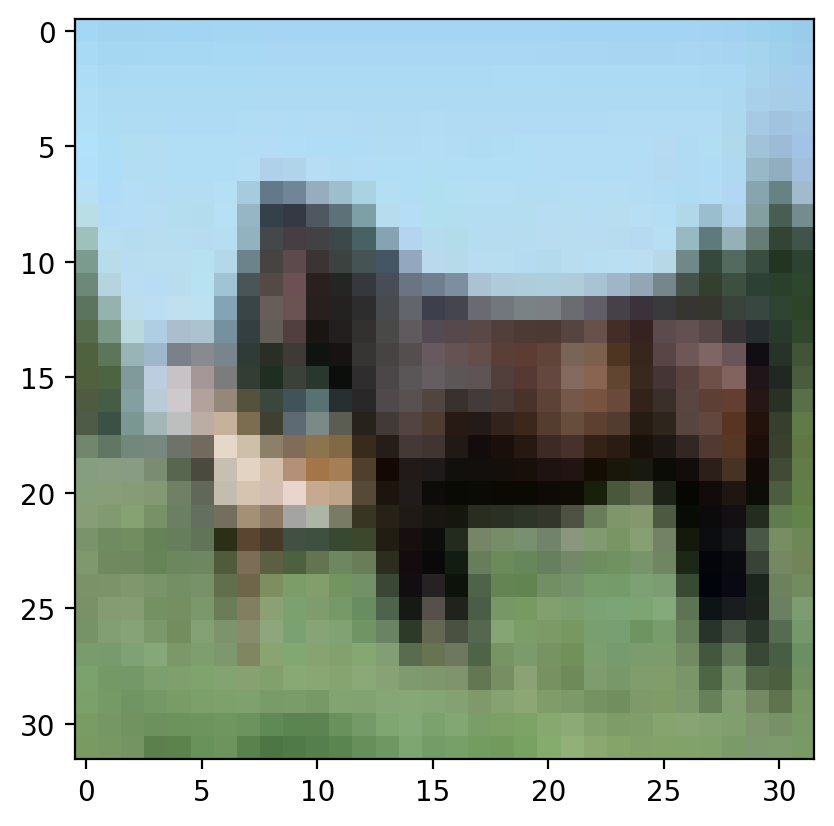

In [21]:
# HORSE
plt.imshow(x_train[12]);

# PreProcessing

In [22]:
x_train[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

In [23]:
x_train[0].shape

(32, 32, 3)

In [24]:
x_train.max()

np.uint8(255)

In [25]:
x_train = x_train/225

In [26]:
x_test = x_test/255

In [27]:
x_train.shape

(50000, 32, 32, 3)

In [28]:
x_test.shape

(10000, 32, 32, 3)

## Labels

In [29]:
from tensorflow.keras.utils import to_categorical

In [30]:
y_train.shape

(50000, 1)

In [31]:
y_train[0]

array([6], dtype=uint8)

In [32]:
y_cat_train = to_categorical(y_train,10)

In [33]:
y_cat_train.shape

(50000, 10)

In [34]:
y_cat_train[0]

array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])

In [35]:
y_cat_test = to_categorical(y_test,10)

----------
# Building the Model

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten

In [38]:
x_train[0].shape

(32, 32, 3)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         1,568 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,568 (6.12 KB)

 Trainable params: 1,568 (6.12 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(4,4), input_shape=(32, 32, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 29, 29, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,568 (6.12 KB)

 Trainable params: 1,568 (6.12 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
model = Sequential()

## FIRST SET OF LAYERS

# CONVOLUTIONAL LAYER
model.add(Conv2D(filters=32, kernel_size=(4,4) , input_shape = (32, 32, 3) , activation='relu',))
# POOLING LAYER
model.add(MaxPool2D(pool_size=(2, 2)))

## SECOND SET OF LAYERS

# CONVOLUTIONAL LAYER
model.add(Conv2D(filters=32, kernel_size=(4,4) , input_shape = (32, 32, 3) , activation='relu',))
# POOLING LAYER
model.add(MaxPool2D(pool_size=(2, 2)))

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,984 (70.25 KB)

 Trainable params: 17,984 (70.25 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model = Sequential()

## FIRST SET OF LAYERS

# CONVOLUTIONAL LAYER
model.add(Conv2D(filters=32, kernel_size=(4,4) , input_shape = (32, 32, 3) , activation='relu',))
# POOLING LAYER
model.add(MaxPool2D(pool_size=(2, 2)))

## SECOND SET OF LAYERS

# CONVOLUTIONAL LAYER
model.add(Conv2D(filters=32, kernel_size=(4,4) , input_shape = (32, 32, 3) , activation='relu',))
# POOLING LAYER
model.add(MaxPool2D(pool_size=(2, 2)))

# FLATTEN IMAGES FROM 28 by 28 to 764 BEFORE FINAL LAYER
model.add(Flatten())

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 29, 29, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,984 (70.25 KB)

 Trainable params: 17,984 (70.25 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model = Sequential()

## FIRST SET OF LAYERS

# CONVOLUTIONAL LAYER
model.add(Conv2D(filters=32, kernel_size=(4,4) , input_shape = (32, 32, 3) , activation='relu',))
# POOLING LAYER
model.add(MaxPool2D(pool_size=(2, 2)))

## SECOND SET OF LAYERS

# CONVOLUTIONAL LAYER
model.add(Conv2D(filters=32, kernel_size=(4,4) , input_shape = (32, 32, 3) , activation='relu',))
# POOLING LAYER
model.add(MaxPool2D(pool_size=(2, 2)))

# FLATTEN IMAGES FROM 28 by 28 to 764 BEFORE FINAL LAYER
model.add(Flatten())

# 256 NEURONS IN DENSE HIDDEN LAYER (YOU CAN CHANGE THIS NUMBER OF NEURONS)
model.add(Dense(256, activation='relu'))

# LAST LAYER IS THE CLASSIFIER, THUS 10 POSSIBLE CLASSES
model.add(Dense(10, activation='softmax'))


model.compile(loss='categorical_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

In [48]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 11, 11, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       205,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,610 (881.29 KB)

 Trainable params: 225,610 (881.29 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
from tensorflow.keras.callbacks import EarlyStopping

In [50]:
early_stop = EarlyStopping(monitor='val_loss',patience=3)

In [51]:
model.fit(x_train,
          y_cat_train,
          epochs=15,
          validation_data=(x_test,y_cat_test),
          callbacks=[early_stop])

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.4514 - loss: 1.5348 - val_accuracy: 0.5359 - val_loss: 1.3031
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5870 - loss: 1.1746 - val_accuracy: 0.5870 - val_loss: 1.1647
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6464 - loss: 1.0179 - val_accuracy: 0.6476 - val_loss: 1.0247
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6863 - loss: 0.9060 - val_accuracy: 0.6561 - val_loss: 0.9976
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7189 - loss: 0.8193 - val_accuracy: 0.6505 - val_loss: 1.0518
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7422 - loss: 0.7544 - val_accuracy: 0.6733 - val_loss: 1.0449
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7603 - loss: 0.6990 - val_accuracy: 0.6490 - val_loss: 1.1706


In [42]:
# Careful, don't overwrite our file!
# model.save('cifar_10epochs.h5')

In [52]:
losses = pd.DataFrame(model.history.history)

In [53]:
losses.head()

,accuracy,loss,val_accuracy,val_loss
0,0.45142,1.534764,0.5359,1.303109
1,0.58696,1.174625,0.5870,1.164742
2,0.64638,1.017918,0.6476,1.024693
3,0.68634,0.905968,0.6561,0.997581
4,0.71890,0.819307,0.6505,1.051841


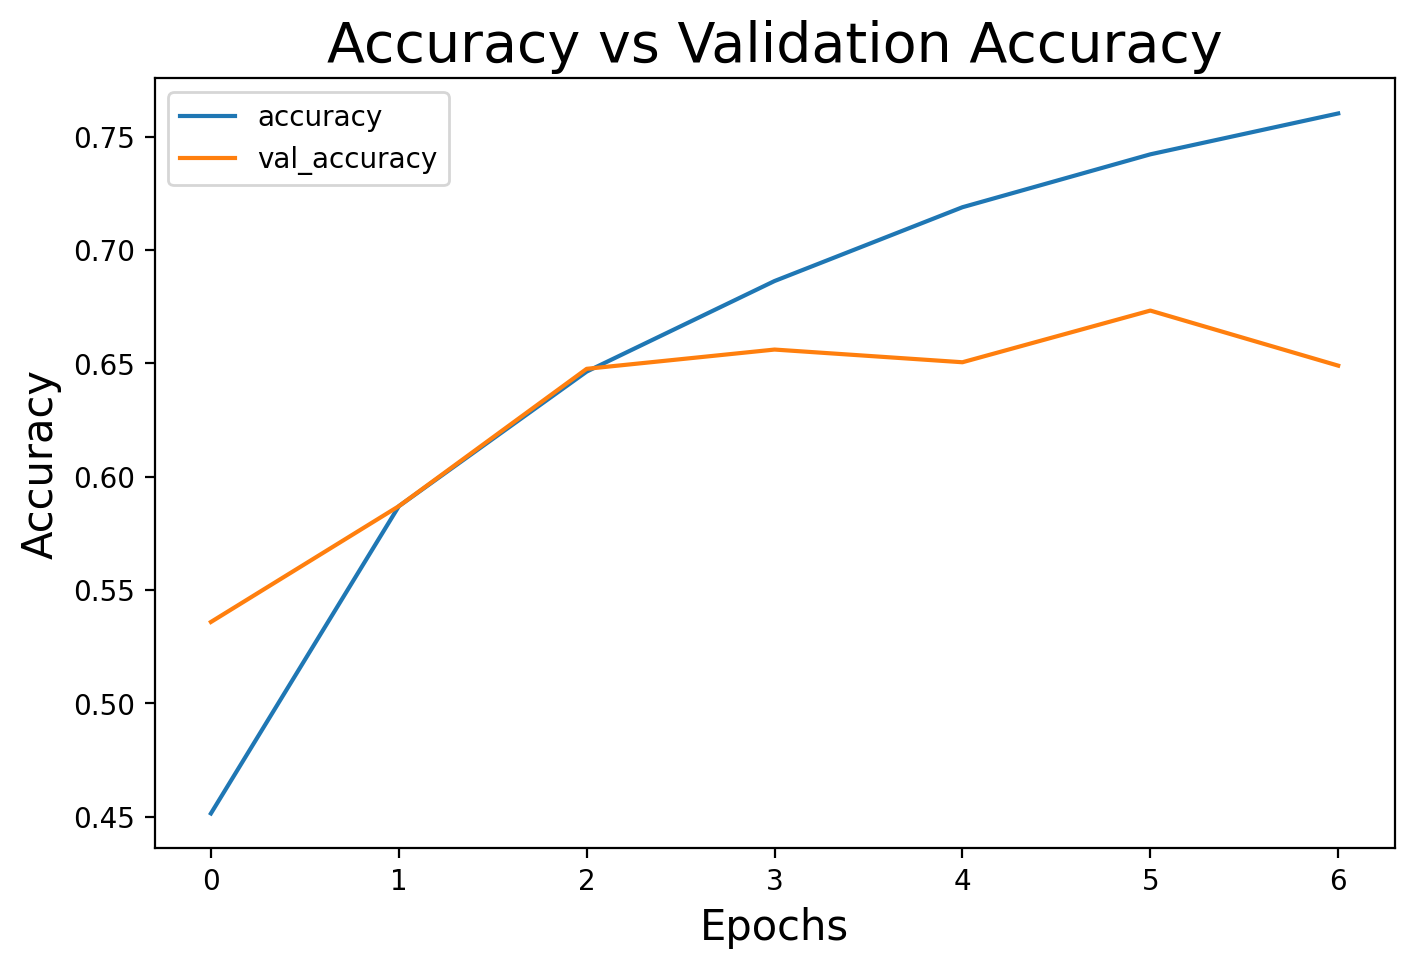

In [55]:
losses[['accuracy','val_accuracy']].plot(figsize=(8,5))
plt.title('Accuracy vs Validation Accuracy' , fontsize=20)
plt.xlabel('Epochs' , fontsize=15)
plt.ylabel('Accuracy' , fontsize=15)
plt.show()

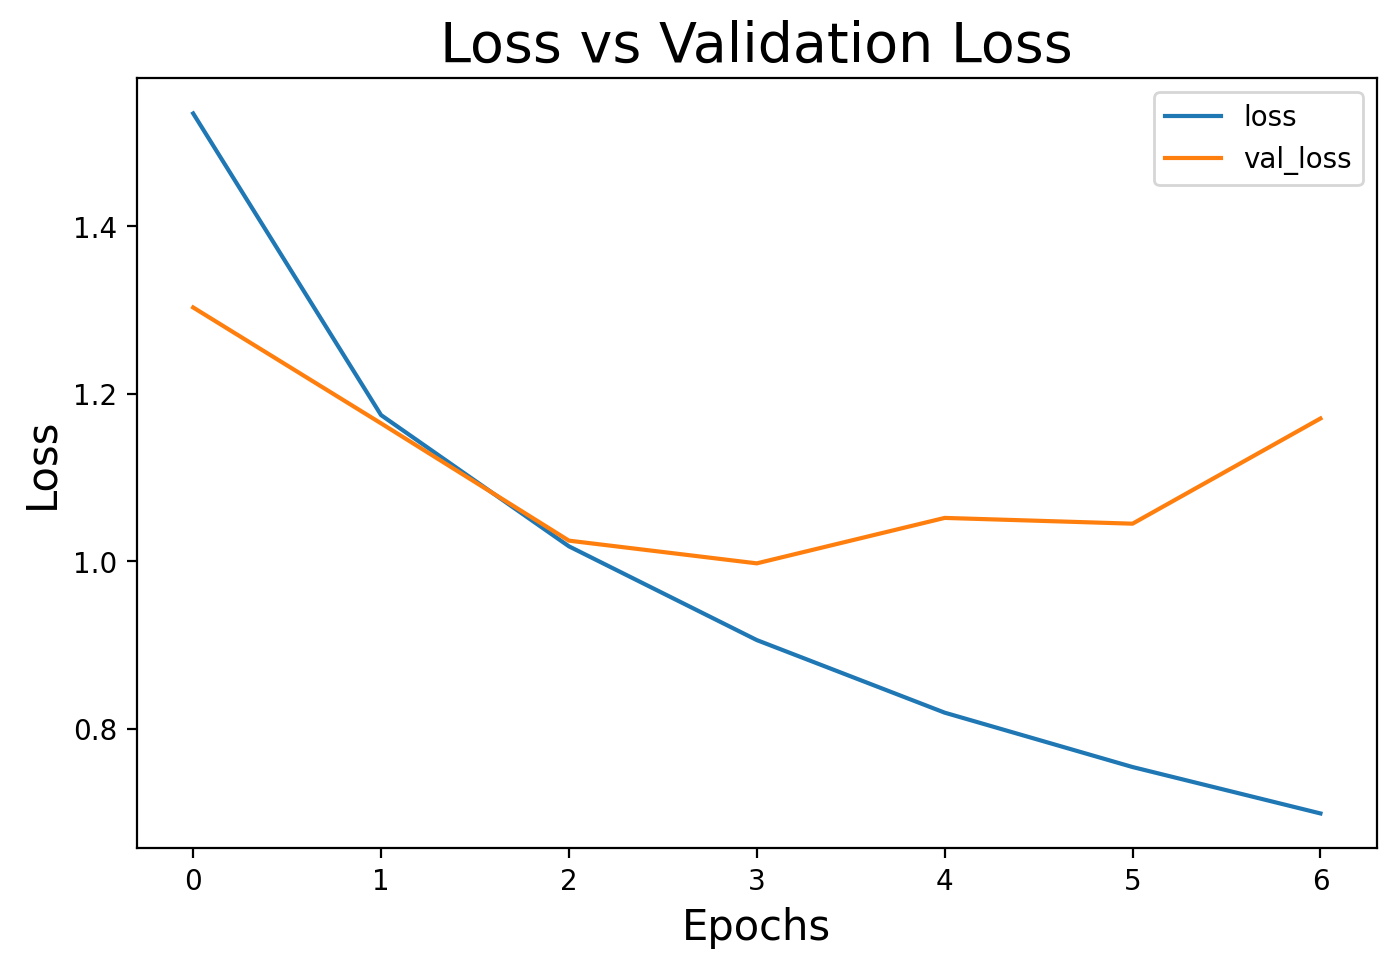

In [56]:
losses[['loss','val_loss']].plot(figsize=(8,5))
plt.title('Loss vs Validation Loss', fontsize=20)
plt.xlabel('Epochs', fontsize=15)
plt.ylabel('Loss', fontsize=15)
plt.show()

In [57]:
model.metrics_names

['loss', 'compile_metrics']

In [58]:
print(model.metrics_names)
print(model.evaluate(x_test,y_cat_test,verbose=0))

['loss', 'compile_metrics']
[1.1705622673034668, 0.6489999890327454]


In [60]:
from sklearn.metrics import classification_report,confusion_matrix

predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [62]:
print(classification_report(y_test,np.argmax(predictions , axis=1)))

              precision    recall  f1-score   support

           0       0.79      0.56      0.66      1000
           1       0.89      0.70      0.78      1000
           2       0.47      0.66      0.55      1000
           3       0.46      0.50      0.48      1000
           4       0.49      0.77      0.60      1000
           5       0.67      0.42      0.52      1000
           6       0.73      0.71      0.72      1000
           7       0.78      0.69      0.73      1000
           8       0.70      0.80      0.75      1000
           9       0.84      0.68      0.75      1000

    accuracy                           0.65     10000
   macro avg       0.68      0.65      0.65     10000
weighted avg       0.68      0.65      0.65     10000



In [65]:
confusion_matrix(y_test,np.argmax(predictions , axis=1))

array([[562,  12, 121,  24,  67,   4,  19,  14, 165,  12],
       [ 29, 699,  35,  33,  28,   8,  24,   7,  62,  75],
       [ 28,   0, 660,  59, 142,  25,  49,  19,  15,   3],
       [  5,   3, 123, 500, 149,  92,  82,  24,  15,   7],
       [  5,   1,  94,  46, 769,  12,  21,  38,  13,   1],
       [  5,   0, 133, 225, 125, 421,  36,  48,   5,   2],
       [  3,   2,  77,  78, 102,  15, 709,  10,   3,   1],
       [  6,   0,  70,  42, 141,  32,   7, 692,   2,   8],
       [ 37,  11,  39,  36,  31,   7,  14,   5, 802,  18],
       [ 30,  54,  38,  50,  29,  16,  15,  31,  61, 676]])

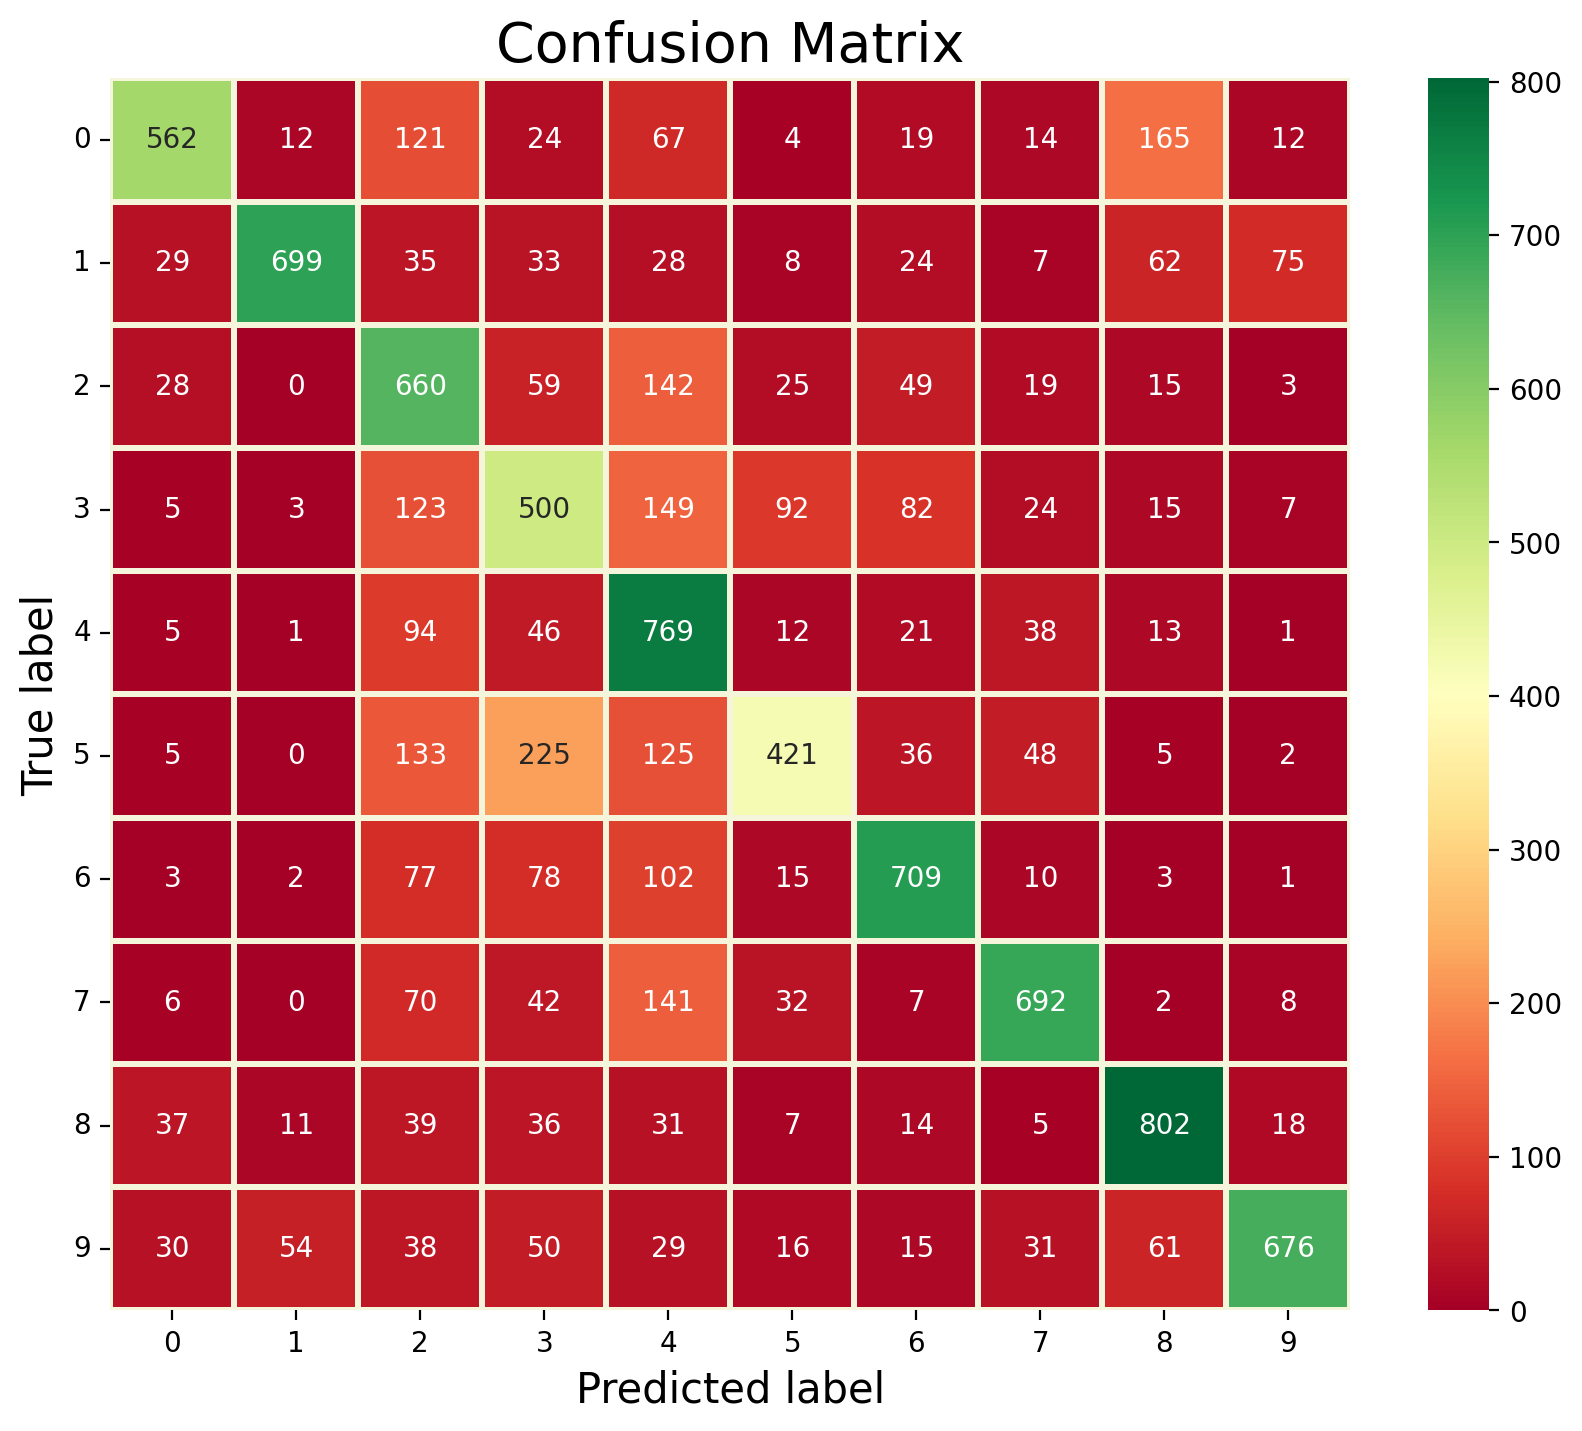

In [74]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(y_test,np.argmax(predictions , axis=1)) , annot=True , linecolor='beige', lw=1.5 , fmt='d' , cmap='RdYlGn')
plt.title('Confusion Matrix', fontsize=20)
# https://github.com/matplotlib/matplotlib/issues/14751
plt.yticks(rotation=0)
plt.ylabel('True label' , fontsize=15)
plt.xlabel('Predicted label', fontsize=15)
plt.show()

# Predicting a given image

In [75]:
my_image = x_test[16]

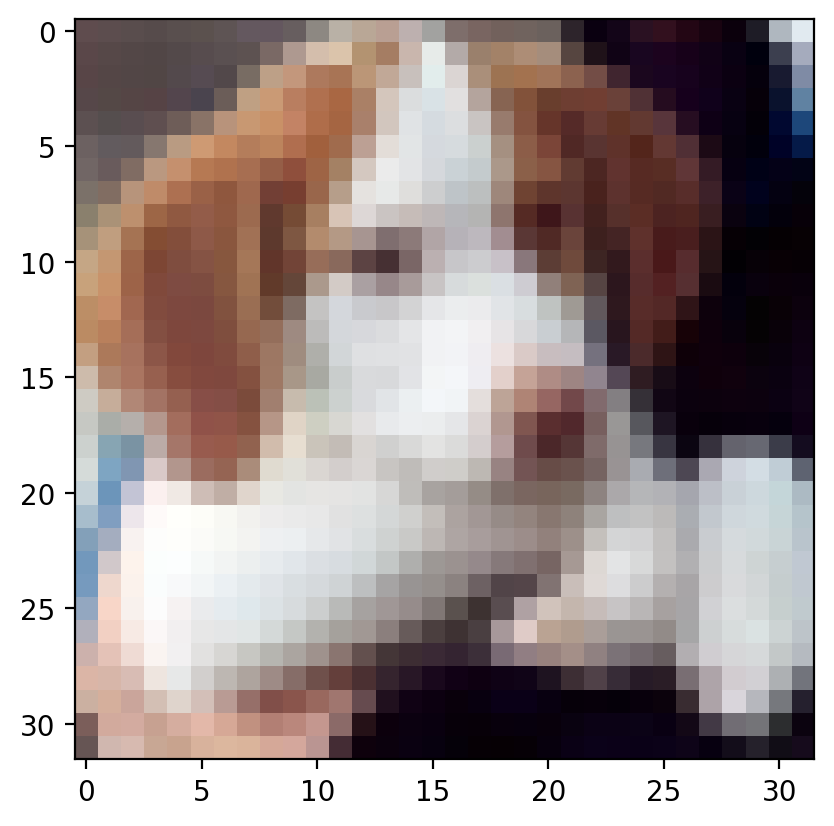

In [77]:
plt.imshow(my_image);

In [78]:
# SHAPE --> (num_images,width,height,color_channels)
model.predict(my_image.reshape(1,32,32,3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step


array([[2.8543791e-05, 2.4231488e-06, 3.6458278e-03, 1.2804946e-01,
        4.2382741e-05, 8.6585146e-01, 3.8392344e-04, 1.9708246e-03,
        1.0604268e-05, 1.4411451e-05]], dtype=float32)

In [79]:
np.argmax(model.predict(my_image.reshape(1,32,32,3)), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([5])

In [ ]:
# 5 is DOG
# https://www.cs.toronto.edu/~kriz/cifar.html